In [1]:
import torch

In [2]:
print(torch.cuda.is_available)

<function is_available at 0x7821eb5e0ae0>


In [3]:
print(torch.cuda.get_device_name(0))

Tesla T4


In [2]:
# Install kaggle library
!pip install kaggle

In [3]:
import os

# Create kaggle folder
os.makedirs("/root/.kaggle", exist_ok=True)

In [4]:
# Copy kaggle.json
!cp kaggle.json /root/.kaggle/

In [5]:
# Give permission
!chmod 600 /root/.kaggle/kaggle.json

In [6]:
!kaggle datasets download -d mateuszbuda/lgg-mri-segmentation

Dataset URL: https://www.kaggle.com/datasets/mateuszbuda/lgg-mri-segmentation
License(s): CC-BY-NC-SA-4.0
100% 714M/714M [00:42<00:00, 17.7MB/s]



In [7]:
!unzip lgg-mri-segmentation.zip

Streaming output truncated to the last 5000 lines.
  inflating: lgg-mri-segmentation/kaggle_3m/TCGA_DU_7294_19890104/TCGA_DU_7294_19890104_9_mask.tif  
  inflating: lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_1.tif  
  inflating: lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_10.tif  
  inflating: lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_10_mask.tif  
  inflating: lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_11.tif  
  inflating: lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_11_mask.tif  
  inflating: lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_12.tif  
  inflating: lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_12_mask.tif  
  inflating: lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_13.tif  
  inflating: lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_1

In [8]:
import os

print(os.listdir())

['.config', 'lgg-mri-segmentation', 'kaggle_3m', 'kaggle.json', 'lgg-mri-segmentation.zip', 'sample_data']


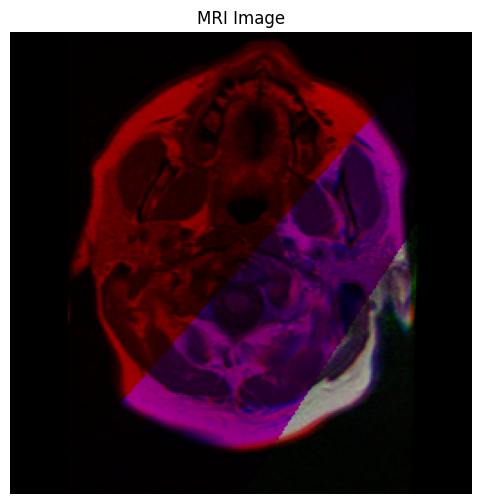

In [9]:
import cv2
import matplotlib.pyplot as plt

# Read image
image = cv2.imread("kaggle_3m/TCGA_CS_4944_20010208/TCGA_CS_4944_20010208_1.tif")

# Convert BGR to RGB
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Show image
plt.figure(figsize=(6,6))
plt.imshow(image)
plt.title("MRI Image")
plt.axis("off")
plt.show()

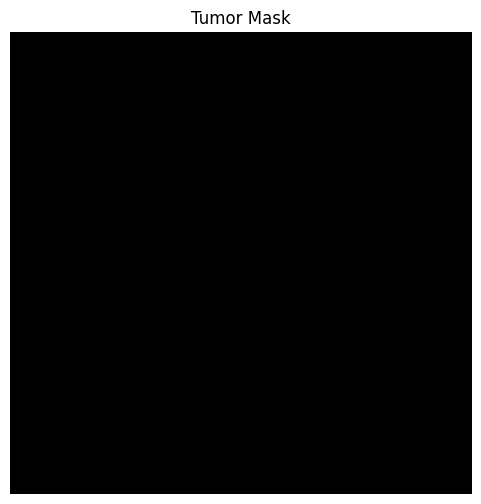

In [10]:
mask = cv2.imread(
    "kaggle_3m/TCGA_CS_4944_20010208/TCGA_CS_4944_20010208_1_mask.tif",
    cv2.IMREAD_GRAYSCALE
)

plt.figure(figsize=(6,6))
plt.imshow(mask, cmap='gray')
plt.title("Tumor Mask")
plt.axis("off")
plt.show()

In [11]:
import numpy as np

print("Shape:", mask.shape)

print("Unique values:", np.unique(mask))

print("Maximum value:", mask.max())

print("Minimum value:", mask.min())

Shape: (256, 256)
Unique values: [0]
Maximum value: 0
Minimum value: 0


In [13]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [14]:
dataset_path = "kaggle_3m"

image_paths = []
mask_paths = []

In [15]:
for folder in os.listdir(dataset_path):

    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):

        for file in os.listdir(folder_path):

            if file.endswith(".tif") and "mask" not in file:

                image_path = os.path.join(folder_path, file)

                mask_path = image_path.replace(".tif", "_mask.tif")

                if os.path.exists(mask_path):

                    image_paths.append(image_path)
                    mask_paths.append(mask_path)


In [16]:
print("Total Images:", len(image_paths))
print("Total Masks:", len(mask_paths))

Total Images: 3929
Total Masks: 3929


In [17]:
filtered_images = []
filtered_masks = []

In [18]:
for img_path, mask_path in zip(image_paths, mask_paths):

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if mask is not None:

        # Check if tumor exists
        if np.max(mask) > 0:

            filtered_images.append(img_path)
            filtered_masks.append(mask_path)

In [19]:
print("Filtered Images:", len(filtered_images))
print("Filtered Masks:", len(filtered_masks))

Filtered Images: 1373
Filtered Masks: 1373


In [20]:
IMG_SIZE = 256

In [21]:
def preprocess_image(image_path):

    # Read image
    image = cv2.imread(image_path)

    # Convert BGR → RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Resize
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

    # Normalize
    image = image / 255.0

    return image

In [22]:
def preprocess_mask(mask_path):

    # Read mask
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    # Resize
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))

    # Convert to binary
    mask = mask / 255.0

    # Expand dimension
    mask = np.expand_dims(mask, axis=-1)

    return mask

In [23]:
sample_image = preprocess_image(filtered_images[0])

sample_mask = preprocess_mask(filtered_masks[0])

print(sample_image.shape)
print(sample_mask.shape)

(256, 256, 3)
(256, 256, 1)


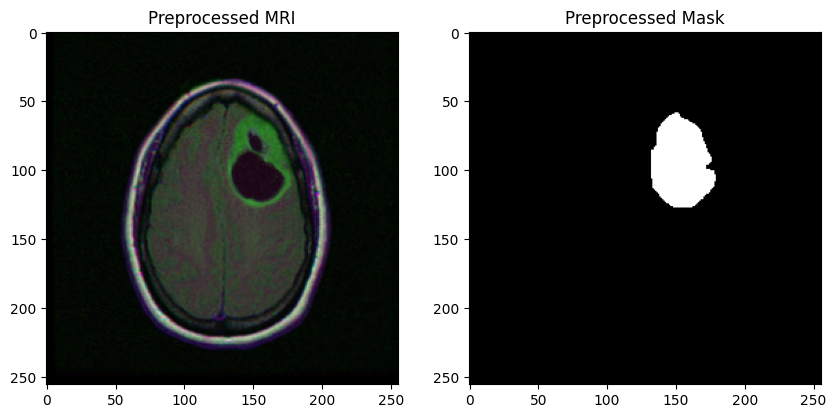

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(10,5))

ax[0].imshow(sample_image)
ax[0].set_title("Preprocessed MRI")

ax[1].imshow(sample_mask.squeeze(), cmap='gray')
ax[1].set_title("Preprocessed Mask")

plt.show()

In [25]:
X_train, X_val, y_train, y_val = train_test_split(
    filtered_images,
    filtered_masks,
    test_size=0.2,
    random_state=42
)

In [26]:
print("Training Images:", len(X_train))
print("Validation Images:", len(X_val))


Training Images: 1098
Validation Images: 275


In [27]:
import torch
from torch.utils.data import Dataset, DataLoader

In [28]:
class BrainTumorDataset(Dataset):

    def __init__(self, image_paths, mask_paths):

        self.image_paths = image_paths
        self.mask_paths = mask_paths

    def __len__(self):

        return len(self.image_paths)

    def __getitem__(self, index):

        # Load image
        image = preprocess_image(self.image_paths[index])

        # Load mask
        mask = preprocess_mask(self.mask_paths[index])

        # Convert to tensor
        image = torch.tensor(image, dtype=torch.float32)

        mask = torch.tensor(mask, dtype=torch.float32)

        # Change dimensions
        image = image.permute(2, 0, 1)

        mask = mask.permute(2, 0, 1)

        return image, mask

In [29]:
train_dataset = BrainTumorDataset(X_train, y_train)

val_dataset = BrainTumorDataset(X_val, y_val)

In [30]:
BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [31]:
images, masks = next(iter(train_loader))

print("Images Shape:", images.shape)

print("Masks Shape:", masks.shape)

Images Shape: torch.Size([8, 3, 256, 256])
Masks Shape: torch.Size([8, 1, 256, 256])


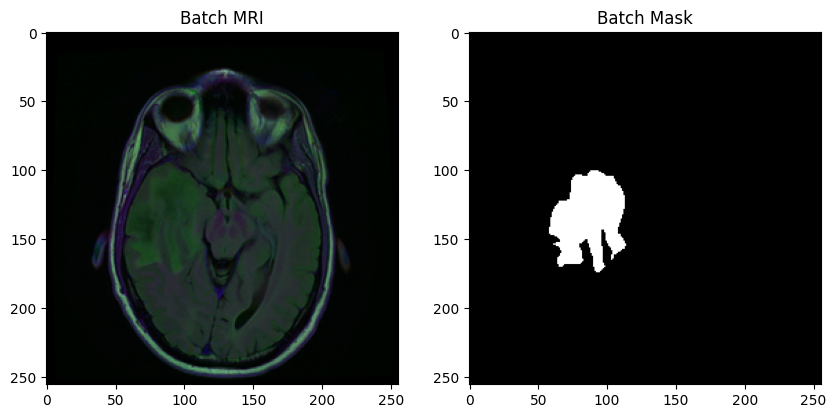

In [32]:
sample_image = images[0].permute(1, 2, 0).numpy()

sample_mask = masks[0].squeeze().numpy()

fig, ax = plt.subplots(1, 2, figsize=(10,5))

ax[0].imshow(sample_image)
ax[0].set_title("Batch MRI")

ax[1].imshow(sample_mask, cmap='gray')
ax[1].set_title("Batch Mask")

plt.show()

In [33]:
import albumentations as A

In [34]:
train_transform = A.Compose([

    A.HorizontalFlip(p=0.5),

    A.VerticalFlip(p=0.5),

    A.Rotate(limit=20, p=0.5),

    A.RandomBrightnessContrast(p=0.3),

    A.GaussianBlur(p=0.2),

    A.ElasticTransform(p=0.3),

])

In [35]:
class BrainTumorDataset(Dataset):

    def __init__(self, image_paths, mask_paths, transform=None):

        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):

        return len(self.image_paths)

    def __getitem__(self, index):

        # Load image
        image = preprocess_image(self.image_paths[index])

        # Load mask
        mask = preprocess_mask(self.mask_paths[index])

        # Apply augmentation
        if self.transform:

            augmented = self.transform(
                image=image,
                mask=mask
            )

            image = augmented["image"]
            mask = augmented["mask"]

        # Convert to tensor
        image = torch.tensor(image, dtype=torch.float32)

        mask = torch.tensor(mask, dtype=torch.float32)

        # Channel first
        image = image.permute(2, 0, 1)

        mask = mask.permute(2, 0, 1)

        return image, mask

In [36]:
train_dataset = BrainTumorDataset(
    X_train,
    y_train,
    transform=train_transform
)

In [37]:
val_dataset = BrainTumorDataset(
    X_val,
    y_val,
    transform=None
)

In [38]:
BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

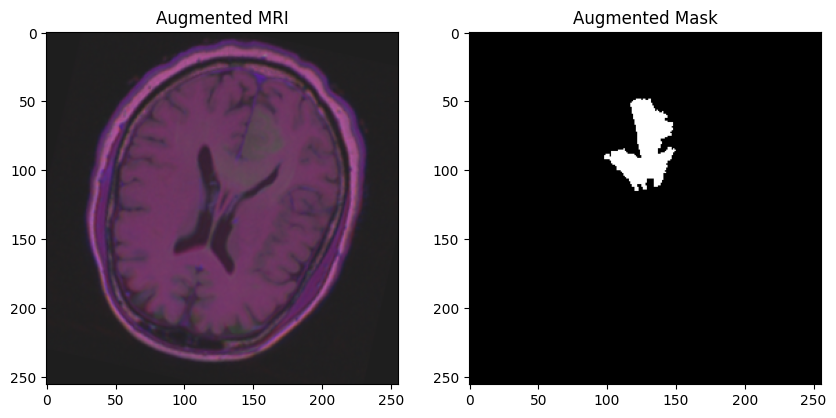

In [39]:
images, masks = next(iter(train_loader))

sample_image = images[0].permute(1, 2, 0).numpy()

sample_mask = masks[0].squeeze().numpy()

fig, ax = plt.subplots(1, 2, figsize=(10,5))

ax[0].imshow(sample_image)
ax[0].set_title("Augmented MRI")

ax[1].imshow(sample_mask, cmap='gray')
ax[1].set_title("Augmented Mask")

plt.show()

In [40]:
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 14.0 MB/s eta 0:00:00


In [41]:
import segmentation_models_pytorch as smp
import torch.nn as nn

In [42]:
model = smp.Unet(

    encoder_name="resnet34",

    encoder_weights="imagenet",

    in_channels=3,

    classes=1,

    activation=None
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

print(device)

cuda


In [44]:
images, masks = next(iter(train_loader))

images = images.to(device)

outputs = model(images)

print("Output Shape:", outputs.shape)

Output Shape: torch.Size([8, 1, 256, 256])


In [45]:
total_params = sum(p.numel() for p in model.parameters())

print("Total Parameters:", total_params)

Total Parameters: 24436369


In [46]:
!pip install torchinfo

In [47]:
from torchinfo import summary

summary(model, input_size=(8,3,256,256))

Layer (type:depth-idx)                        Output Shape              Param #
Unet                                          [8, 1, 256, 256]          --
├─ResNetEncoder: 1-1                          [8, 3, 256, 256]          --
│    └─Conv2d: 2-1                            [8, 64, 128, 128]         9,408
│    └─BatchNorm2d: 2-2                       [8, 64, 128, 128]         128
│    └─ReLU: 2-3                              [8, 64, 128, 128]         --
│    └─MaxPool2d: 2-4                         [8, 64, 64, 64]           --
│    └─Sequential: 2-5                        [8, 64, 64, 64]           --
│    │    └─BasicBlock: 3-1                   [8, 64, 64, 64]           73,984
│    │    └─BasicBlock: 3-2                   [8, 64, 64, 64]           73,984
│    │    └─BasicBlock: 3-3                   [8, 64, 64, 64]           73,984
│    └─Sequential: 2-6                        [8, 128, 32, 32]          --
│    │    └─BasicBlock: 3-4                   [8, 128, 32, 32]          230,144

In [48]:
import torch.nn.functional as F

In [49]:
def dice_loss(pred, target, smooth=1e-5):

    pred = torch.sigmoid(pred)

    pred = pred.contiguous()

    target = target.contiguous()

    intersection = (pred * target).sum(dim=(2,3))

    union = pred.sum(dim=(2,3)) + target.sum(dim=(2,3))

    dice = (2.0 * intersection + smooth) / (union + smooth)

    loss = 1 - dice.mean()

    return loss

In [50]:
optimizer = torch.optim.Adam(

    model.parameters(),

    lr=1e-4
)

In [51]:
def dice_score(pred, target, smooth=1e-5):

    pred = torch.sigmoid(pred)

    pred = (pred > 0.5).float()

    intersection = (pred * target).sum(dim=(2,3))

    union = pred.sum(dim=(2,3)) + target.sum(dim=(2,3))

    dice = (2 * intersection + smooth) / (union + smooth)

    return dice.mean().item()

In [53]:
def combined_loss(pred, target):
    bce_loss = F.binary_cross_entropy_with_logits(pred, target)
    return bce_loss + dice_loss(pred, target)

images, masks = next(iter(train_loader))

images = images.to(device)

masks = masks.to(device)

outputs = model(images)

loss = combined_loss(outputs, masks)

print("Loss:", loss.item())

Loss: 1.6719956398010254


In [54]:
score = dice_score(outputs, masks)

print("Dice Score:", score)

Dice Score: 0.07015492022037506


In [55]:
from tqdm import tqdm

In [56]:
def train_one_epoch(model, loader, optimizer, device):

    model.train()

    total_loss = 0
    total_dice = 0

    for images, masks in tqdm(loader):

        # Move to GPU
        images = images.to(device)
        masks = masks.to(device)

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = combined_loss(outputs, masks)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Metrics
        total_loss += loss.item()

        total_dice += dice_score(outputs, masks)

    avg_loss = total_loss / len(loader)

    avg_dice = total_dice / len(loader)

    return avg_loss, avg_dice

In [57]:
def validate_one_epoch(model, loader, device):

    model.eval()

    total_loss = 0
    total_dice = 0

    with torch.no_grad():

        for images, masks in tqdm(loader):

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = combined_loss(outputs, masks)

            total_loss += loss.item()

            total_dice += dice_score(outputs, masks)

    avg_loss = total_loss / len(loader)

    avg_dice = total_dice / len(loader)

    return avg_loss, avg_dice

In [58]:
EPOCHS = 20

best_dice = 0

In [59]:
for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # Train
    train_loss, train_dice = train_one_epoch(
        model,
        train_loader,
        optimizer,
        device
    )

    # Validate
    val_loss, val_dice = validate_one_epoch(
        model,
        val_loader,
        device
    )

    # Print metrics
    print(f"Train Loss: {train_loss:.4f}")

    print(f"Train Dice: {train_dice:.4f}")

    print(f"Val Loss: {val_loss:.4f}")

    print(f"Val Dice: {val_dice:.4f}")

    # Save best model
    if val_dice > best_dice:

        best_dice = val_dice

        torch.save(model.state_dict(), "best_model.pth")

        print("Best model saved!")


Epoch 1/20


100%|██████████| 35/35 [00:01<00:00, 21.26it/s]


Train Loss: 1.2434
Train Dice: 0.4129
Val Loss: 1.0428
Val Dice: 0.5946
Best model saved!

Epoch 2/20


100%|██████████| 35/35 [00:01<00:00, 20.90it/s]


Train Loss: 0.9416
Train Dice: 0.5759
Val Loss: 0.8281
Val Dice: 0.6817
Best model saved!

Epoch 3/20


...

Train Loss: 0.3078
Train Dice: 0.7485
Val Loss: 0.2146
Val Dice: 0.8220
Best model saved!

Epoch 19/20


100%|██████████| 35/35 [00:01<00:00, 21.47it/s]


Train Loss: 0.2900
Train Dice: 0.7642
Val Loss: 0.2142
Val Dice: 0.8238
Best model saved!

Epoch 20/20


100%|██████████| 35/35 [00:01<00:00, 21.62it/s]


Train Loss: 0.2892
Train Dice: 0.7649
Val Loss: 0.2090
Val Dice: 0.8290
Best model saved!


In [60]:
model.load_state_dict(torch.load("best_model.pth"))

<All keys matched successfully>

In [61]:
from google.colab import files

files.download("best_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [62]:
model.load_state_dict(torch.load("best_model.pth"))

model.eval()

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [63]:
def predict_mask(model, image_path, device):

    # Preprocess image
    image = preprocess_image(image_path)

    # Convert to tensor
    image_tensor = torch.tensor(
        image,
        dtype=torch.float32
    )

    # Channel first
    image_tensor = image_tensor.permute(2, 0, 1)

    # Add batch dimension
    image_tensor = image_tensor.unsqueeze(0)

    # Move to GPU
    image_tensor = image_tensor.to(device)

    # Prediction
    with torch.no_grad():

        output = model(image_tensor)

        output = torch.sigmoid(output)

    # Convert to numpy
    prediction = output.squeeze().cpu().numpy()

    return image, prediction

In [64]:
test_image_path = X_val[0]

image, prediction = predict_mask(
    model,
    test_image_path,
    device
)

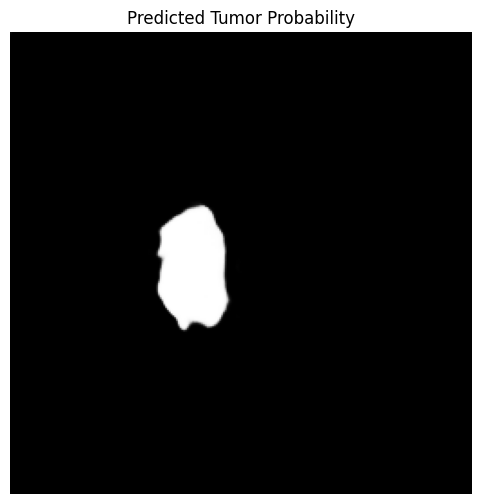

In [65]:
plt.figure(figsize=(6,6))

plt.imshow(prediction, cmap='gray')

plt.title("Predicted Tumor Probability")

plt.axis("off")

plt.show()

In [66]:
binary_prediction = (prediction > 0.5).astype(np.uint8)

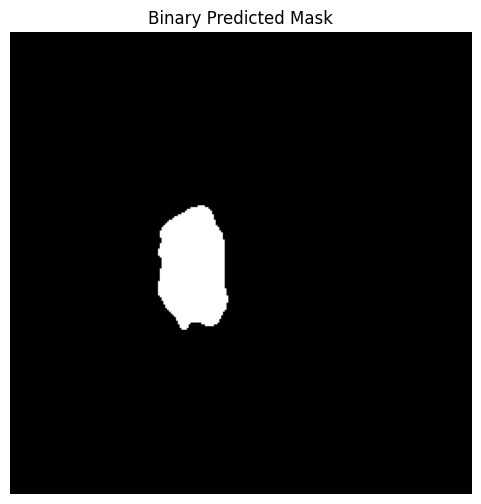

In [67]:
plt.figure(figsize=(6,6))

plt.imshow(binary_prediction, cmap='gray')

plt.title("Binary Predicted Mask")

plt.axis("off")

plt.show()

In [68]:
ground_truth = preprocess_mask(y_val[0])

ground_truth = ground_truth.squeeze()

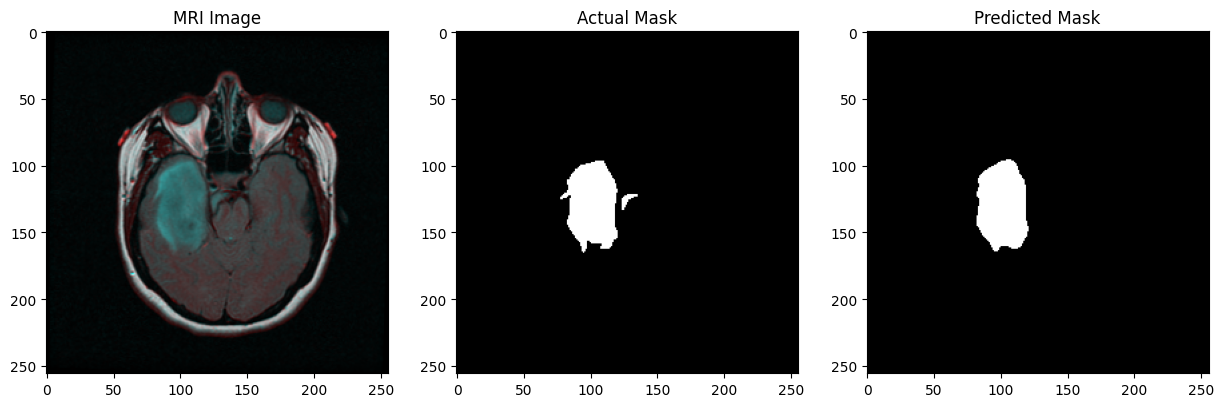

In [69]:
fig, ax = plt.subplots(1, 3, figsize=(15,5))

# MRI
ax[0].imshow(image)
ax[0].set_title("MRI Image")

# Ground Truth
ax[1].imshow(ground_truth, cmap='gray')
ax[1].set_title("Actual Mask")

# Prediction
ax[2].imshow(binary_prediction, cmap='gray')
ax[2].set_title("Predicted Mask")

plt.show()

In [71]:
overlay = image.copy()

overlay[binary_prediction == 1] = [255, 0, 0]

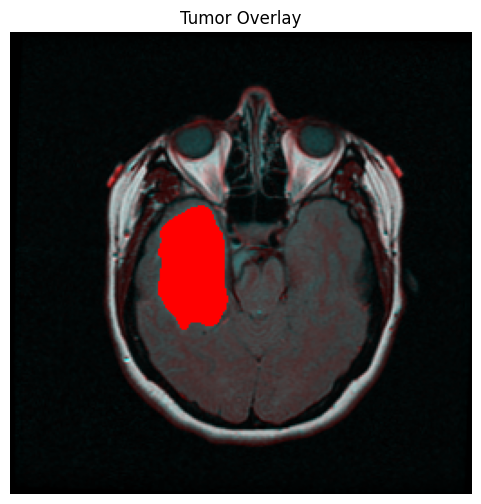

In [72]:
plt.figure(figsize=(6,6))

plt.imshow(overlay)

plt.title("Tumor Overlay")

plt.axis("off")

plt.show()

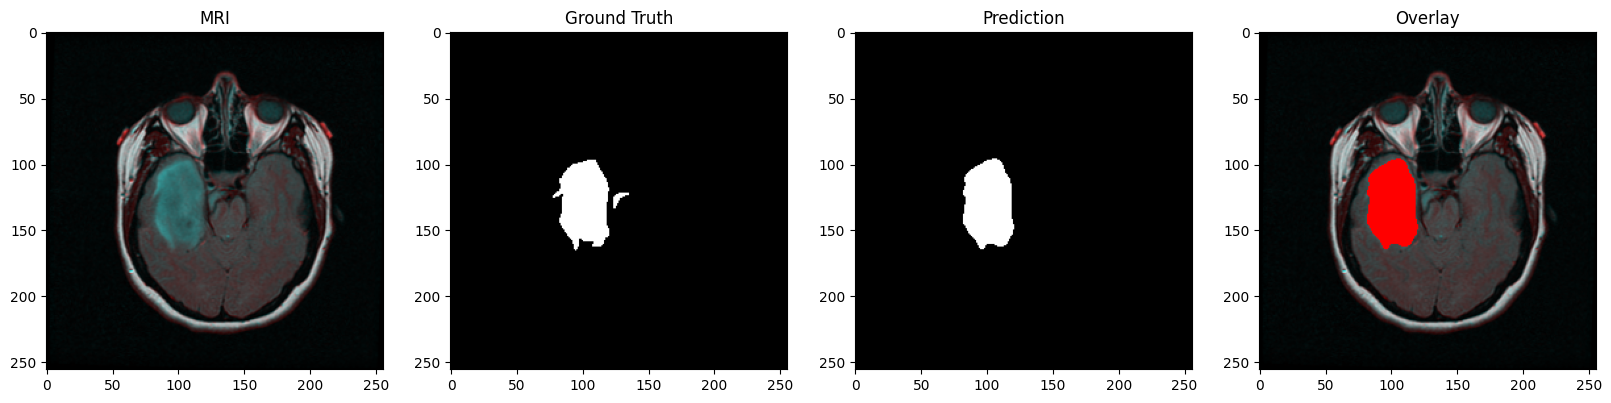

In [73]:
fig, ax = plt.subplots(1, 4, figsize=(20,5))

# Original MRI
ax[0].imshow(image)
ax[0].set_title("MRI")

# Ground Truth
ax[1].imshow(ground_truth, cmap='gray')
ax[1].set_title("Ground Truth")

# Prediction
ax[2].imshow(binary_prediction, cmap='gray')
ax[2].set_title("Prediction")

# Overlay
ax[3].imshow(overlay)
ax[3].set_title("Overlay")

plt.show()

In [75]:
torch.save(model.state_dict(), "brain_tumor_unet.pth")

In [76]:
from google.colab import files

files.download("brain_tumor_unet.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>